In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# load_boston is deprecated due to ethical issues https://scikit-learn.org/1.0/modules/generated/sklearn.datasets.load_boston.html
# Download source: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset
# Using this dataset soley for **educational** purpose

bostonDF = pd.read_csv('/mnt/c/Users/USER/Downloads/boston/BostonHousing.csv')
bostonDF.rename(columns={'crim':'CRIM', 'zn':'ZN', 'indus':'INDUS', 'chas':'CHAS', 'nox':'NOX', 
                         'rm':'RM', 'age':'AGE', 'dis':'DIS', 'rad':'RAD', 'tax':'TAX', 'ptratio':'PTRATIO', 
                         'b':'B', 'lstat':'LSTAT', 'medv':'MEDV'}, inplace=True)
bostonDF.rename(columns={'MEDV':'PRICE'}, inplace=True)

# drop the column 'B' and 'LSTAT' due to ethical issues
bostonDF = bostonDF.drop(columns=['B', 'LSTAT'])

# In this dataset, 5 rooms turned out to be null values. Fill them with the mean of the column.
bostonDF.fillna(bostonDF.mean(), inplace=True)

bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,36.2


$Min(RSS(W) + alpha * W^2)$

$Ridge$: L2 Regularization

$Lasso$: L1 Regularization

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print(' 5 folds의 평균 RMSE: {0:3f}'.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [ -8.901 -29.484 -23.577 -93.274 -47.385]
 5 folds의 개별 RMSE scores:  [2.984 5.43  4.856 9.658 6.884]
 5 folds의 평균 RMSE: 5.962098


In [10]:
alphas = [0, 0.1, 1, 10, 100]

for alpha in alphas:
    ridge = Ridge(alpha = alpha)
    # same as above
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)

    print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE: 6.384
alpha 0.1일 때 5 folds의 평균 RMSE: 6.335
alpha 1일 때 5 folds의 평균 RMSE: 6.152
alpha 10일 때 5 folds의 평균 RMSE: 5.962
alpha 100일 때 5 folds의 평균 RMSE: 6.100


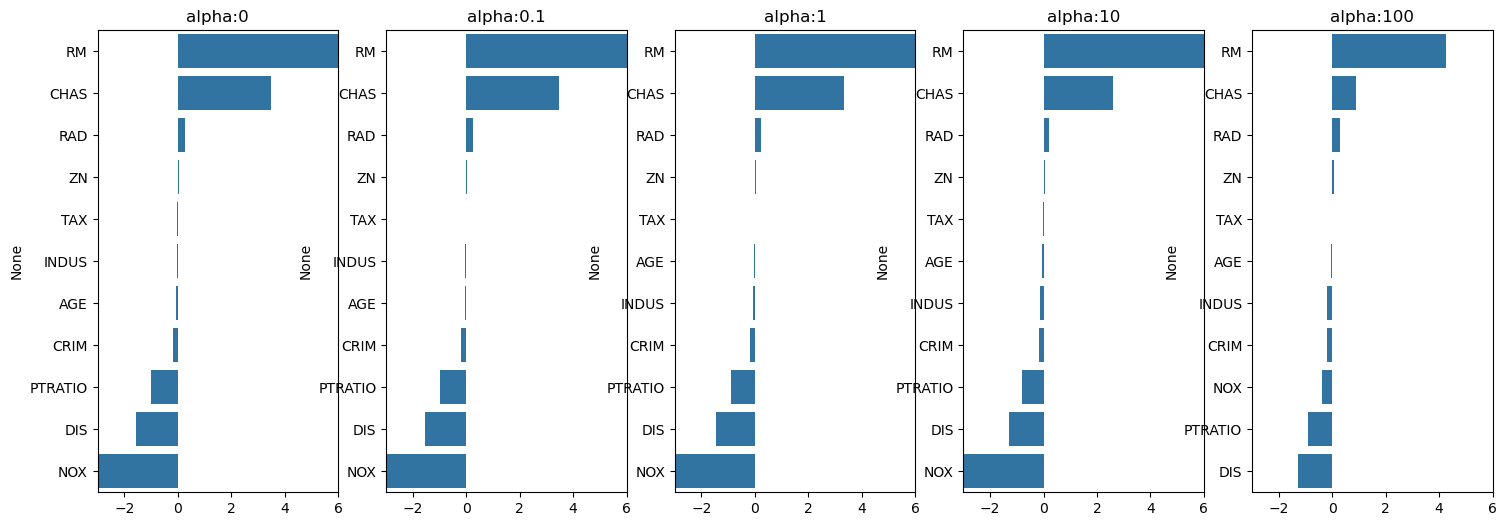

In [16]:
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5)
coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_data, y_target)
    coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
    colname = 'alpha:'+str(alpha)
    coeff_df[colname] = coeff
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])


plt.show()

In [17]:
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,6.070800,6.087056,6.165530,6.051154,4.257640
CHAS,3.487923,3.469868,3.337585,2.596757,0.899998
RAD,0.257052,0.253694,0.235878,0.221658,0.279919
ZN,0.039076,0.039248,0.040254,0.043013,0.052102
TAX,-0.012344,-0.012454,-0.013083,-0.014540,-0.017661
INDUS,-0.039803,-0.045706,-0.078186,-0.127905,-0.177251
AGE,-0.044926,-0.046250,-0.053484,-0.063282,-0.061299
CRIM,-0.184109,-0.183742,-0.181944,-0.183390,-0.205519
PTRATIO,-0.996621,-0.981828,-0.901923,-0.810461,-0.906524
DIS,-1.565724,-1.546336,-1.440546,-1.298511,-1.267201


> L2규제가 회귀 계수의 크기를 감소시키는 데 반해, L1규제는 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거합니다. 이러한 측면에서 L1 규제는 적절한 feature만 회귀에 포함시키는 feature 선택의 특성을 가지고 있습니다.

1. Use cross-validation to get unbiased performance estimates (RMSE)
2. Fit on the full dataset to get the final model's coefficients
3. Use these coefficients to understand feature importance and the effect of regularization

In [18]:
from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None,
                        verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose: print('###### ', model_name, '######')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name == 'Lasso': model = Lasso(alpha=param)
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n,
                                         scoring='neg_mean_squared_error', cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일때 5 folds의 평균 RMSE: {1:3f}'.format(param, avg_rmse))

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
            colname = 'alpha:'+str(param)
            coeff_df[colname] = coeff
    return coeff_df


In [19]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas,
                                     X_data_n=X_data, y_target_n=y_target)

######  Lasso ######
alpha 0.07일때 5 folds의 평균 RMSE: 6.095225
alpha 0.1일때 5 folds의 평균 RMSE: 6.022251
alpha 0.5일때 5 folds의 평균 RMSE: 6.152540
alpha 1일때 5 folds의 평균 RMSE: 6.498198
alpha 3일때 5 folds의 평균 RMSE: 7.733967


In [24]:
sort_column='alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,6.274226,6.225032,5.440985,4.396376,0.063037
CHAS,2.269514,1.799852,0.000000,0.000000,0.000000
RAD,0.205420,0.208510,0.213650,0.201852,0.143192
ZN,0.041743,0.041783,0.041533,0.040826,0.055060
NOX,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
TAX,-0.014655,-0.014930,-0.016257,-0.016727,-0.018588
AGE,-0.065105,-0.064229,-0.055183,-0.045207,-0.019594
INDUS,-0.127565,-0.123161,-0.097345,-0.081680,-0.072133
CRIM,-0.178459,-0.179091,-0.175739,-0.165607,-0.134469
PTRATIO,-0.758160,-0.763988,-0.771556,-0.745639,-0.567892


In [25]:
elastic_alphas=[0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas,
                                       X_data_n=X_data, y_target_n=y_target)

######  ElasticNet ######
alpha 0.07일때 5 folds의 평균 RMSE: 5.982841
alpha 0.1일때 5 folds의 평균 RMSE: 5.975702
alpha 0.5일때 5 folds의 평균 RMSE: 6.192745
alpha 1일때 5 folds의 평균 RMSE: 6.520661
alpha 3일때 5 folds의 평균 RMSE: 7.537347


In [26]:
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,5.981834,5.830584,4.130503,2.826883,0.650357
CHAS,1.981244,1.579109,0.000000,0.000000,0.000000
RAD,0.219888,0.224128,0.261592,0.265908,0.192746
ZN,0.043406,0.044196,0.049717,0.052168,0.053030
TAX,-0.015086,-0.015517,-0.017858,-0.018802,-0.019223
AGE,-0.064176,-0.064184,-0.055707,-0.047098,-0.022267
INDUS,-0.132283,-0.136088,-0.147773,-0.150735,-0.095126
CRIM,-0.183448,-0.185183,-0.195259,-0.192985,-0.155198
PTRATIO,-0.793053,-0.796637,-0.865088,-0.855259,-0.615240
NOX,-0.807856,-0.000000,-0.000000,-0.000000,-0.000000


In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data


    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree,
                                         include_bias=False).fit_transform(scaled_data)
        
    return scaled_data

In [39]:
alphas = [0.1,1,10,100]

scale_methods = [(None, None), ('Standard', None), ('Standard', 2),
                 ('MinMax', None), ('MinMax', 2), ('Log', None), ('Log', 2)]

for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1],
                                    input_data=X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, y_target_n=y_target,
                        verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 6.334932
alpha 1일때 5 folds의 평균 RMSE: 6.152446
alpha 10일때 5 folds의 평균 RMSE: 5.962098
alpha 100일때 5 folds의 평균 RMSE: 6.099599

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 6.381177
alpha 1일때 5 folds의 평균 RMSE: 6.359715
alpha 10일때 5 folds의 평균 RMSE: 6.203857
alpha 100일때 5 folds의 평균 RMSE: 6.028192

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일때 5 folds의 평균 RMSE: 10.417149
alpha 1일때 5 folds의 평균 RMSE: 8.629576
alpha 10일때 5 folds의 평균 RMSE: 6.424821
alpha 100일때 5 folds의 평균 RMSE: 5.285642

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 6.329748
alpha 1일때 5 folds의 평균 RMSE: 6.124571
alpha 10일때 5 folds의 평균 RMSE: 6.560557
alpha 100일때 5 folds의 평균 RMSE: 7.984350

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일때 5 folds의 평균 RMSE: 6.071915
alpha 1일때 5 folds의 평균 RMSE: 5.186241
alpha 10일때 5 folds의 평균 RMSE: 6.019335
alpha 100일때 5 folds의 평균 RMSE: 7.249275

## 변환 유형:Log, Polynomial Degree:

## $Logistic$ $Regression$

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3,
                                                    random_state=0)

In [53]:
from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

print('accuracy: {0:.3f}, roc_auc:{1:.3f}'.format(accuracy_score(y_test, lr_preds),
                                 roc_auc_score(y_test, lr_preds)))

accuracy: 0.977, roc_auc:0.972


In [56]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)

    print('solver:{0}, accuracy:{1:.3f}, roc_auc:{2:.3f}'.format(solver, accuracy_score(y_test, lr_preds), 
                                                                 roc_auc_score(y_test, lr_preds)))

solver:lbfgs, accuracy:0.977, roc_auc:0.972
solver:liblinear, accuracy:0.982, roc_auc:0.979
solver:newton-cg, accuracy:0.977, roc_auc:0.972
solver:sag, accuracy:0.982, roc_auc:0.979
solver:saga, accuracy:0.982, roc_auc:0.979


In [60]:
from sklearn.model_selection import GridSearchCV

params={'solver': ['liblinear', 'lbfgs'],
         'penalty': ['l2','l1'],
         'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도: {1:.3f}'.format(grid_clf.best_params_,
                                                   grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도: 0.979


/home/jpotw/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/home/jpotw/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/jpotw/miniconda3/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jpotw/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.p